# GraphServe: three-node cluster inference results

This report presents saved live cluster measurements only: one control node and two GPU workers. The single-worker `config-a-baseline` run and mocked local test results are excluded. Historical two-worker A/B results and the newer orchestration run are separate experiments.

## Current system and experiment boundaries

The control node hosts nginx, the Python agent and gateway, two Ray heads, and monitoring. Hosted Superlinked SIE provides embeddings for reranking. Two GPU workers each run a complete Qwen2.5-Coder-7B-Instruct BF16 replica.

User → nginx → agent authentication → Graphify retrieval → hosted SIE → token-aware context → internal nginx → guard/admission → worker placement → bounded priority queue → Ray Serve/vLLM → source verification.

Final profiles use two stable RayServices. Engine settings: BF16, tensor parallel size 1, context length 8192, memory utilization budget 0.9, maximum sequences 8. Baseline disables prefix caching; comparison enables it. Gateway dispatch concurrency is 4 per worker with 8 waiting slots. These are repository settings, not independently captured effective runtime settings for every saved run.

Historical A/B below changed BOTH caching and Ray routing. They cannot isolate the effect of prefix caching. The analyzed class9 repository is the question corpus, not the GraphServe serving implementation.

In [1]:
from pathlib import Path
import json, math, html
from IPython.display import Markdown, SVG, display

ROOT = Path.cwd()
if not (ROOT / "benchmarks").exists() and (ROOT.parent / "benchmarks").exists():
    ROOT = ROOT.parent
if not (ROOT / "benchmarks").exists():
    raise FileNotFoundError("Run this notebook from the GraphServe repository root")

CONFIGS = {
    "A — P2C, cache OFF": ROOT / "benchmarks/config-a-multinode-default",
    "B — affinity, cache ON": ROOT / "benchmarks/config-b-multinode-prefix-aware",
}
summaries = {name: json.loads((path / "summary.json").read_text()) for name, path in CONFIGS.items()}
requests = {name: [json.loads(line) for line in (path / "requests.jsonl").read_text().splitlines()]
            for name, path in CONFIGS.items()}
print("Loaded:", ", ".join(f"{name} ({len(requests[name])} records)" for name in CONFIGS))

Loaded: A — P2C, cache OFF (38 records), B — affinity, cache ON (38 records)


## Two-worker comparison: load-based routing versus prefix-aware routing

Both runs use one K3s control node and two A100 40 GB GPU worker nodes, with one complete Qwen2.5-Coder-7B-Instruct BF16 replica on each worker. A shared RayService manages the two replicas; it is not a single-worker setup. These October 1 measurements predate the newer gateway-selected worker a/b deployment.

| Setting | Configuration A — P2C, cache OFF | Configuration B — affinity, cache ON |
|---|---|---|
| Replica selection | Ray Serve default Power of Two Choices (P2C); no custom router configured | Ray `PrefixCacheAffinityRouter` |
| Routing behavior | Samples two replicas and favors the one with fewer ongoing requests | Prefers matching prefixes when load permits; falls back to load balancing when imbalanced |
| vLLM automatic prefix caching | Disabled (`enable_prefix_caching: false`) | Enabled (`enable_prefix_caching: true`) |
| Prefix-router settings | Not configured | `imbalanced_threshold=2`, `match_rate_threshold=0.1` |
| Model replicas | 2 on separate GPU nodes | 2 on separate GPU nodes |
| Ray maximum ongoing requests | 8 per replica | 8 per replica |

Both use Ray 2.58.0, tensor parallel size 1, an 8192-token context limit, `max_num_seqs=8`, and a 0.9 GPU memory budget. The workload sends repository questions through the full `/questions` application path. Each concurrency phase has 12 measured requests; warmups are excluded from the table.

Configuration A balances observed load without deliberate prefix affinity. Configuration B attempts to improve prefix reuse while retaining load balancing. Routing and caching BOTH change, so this experiment does not isolate caching's effect.

Evidence: [A manifest](benchmarks/config-a-multinode-default/rayservice.yaml), [B manifest](benchmarks/config-b-multinode-prefix-aware/rayservice.yaml). Algorithm reference: [Ray Serve routing policies](https://docs.ray.io/en/latest/serve/llm/architecture/routing-policies.html). Routing descriptions explain the configured policies, not a recovered per-request routing trace.


### How to read the results table

| Column | Meaning |
|---|---|
| Configuration | A: Ray Power of Two Choices with prefix caching OFF. B: Ray PrefixCacheAffinityRouter with prefix caching ON. |
| C | Client concurrency: maximum simultaneous requests, not GPU count. Both configurations have two GPU workers. |
| Success | Successful requests out of the 12 measured requests in that phase. |
| Requests/s | Successful completed requests divided by total phase elapsed time, including time spent waiting for failures. |
| p50 (s) | Median latency of successful full `/questions` requests, including retrieval, SIE, inference and verification. |
| p95 (s) | Interpolated 95th percentile of successful-request latency. With only 12 requests (or eight successes), this tail estimate is uncertain. |
| Tokens/s | Recorded prompt plus completion tokens across returned inference usage, divided by phase duration. Includes recorded retry usage; not decode-only token speed or hidden work from failed calls. |

These are client-observed application measurements, not engine-only TTFT or TPOT. Inspect success counts before comparing latency.


In [2]:
rows = []
for name, summary in summaries.items():
    for phase in summary["phases"]:
        rows.append({"config": name, **phase})

lines = []
lines.append("| Configuration | C | Success | Requests/s | p50 (s) | p95 (s) | Tokens/s |")
lines.append("|---|---:|---:|---:|---:|---:|---:|")
for row in rows:
    lines.append(f"| {row['config']} | {row['concurrency']} | {row['successful']}/{row['requests']} | "
          f"{row['request_throughput_per_s']:.3f} | {row['latency_p50_s']:.2f} | "
          f"{row['latency_p95_s']:.2f} | {row['total_tokens_per_s']:.0f} |")
display(Markdown("\n".join(lines)))


| Configuration | C | Success | Requests/s | p50 (s) | p95 (s) | Tokens/s |
|---|---:|---:|---:|---:|---:|---:|
| A — P2C, cache OFF | 1 | 12/12 | 0.138 | 6.38 | 11.13 | 738 |
| A — P2C, cache OFF | 2 | 12/12 | 0.285 | 6.46 | 10.73 | 1524 |
| A — P2C, cache OFF | 4 | 12/12 | 0.492 | 6.62 | 12.06 | 2633 |
| B — affinity, cache ON | 1 | 12/12 | 0.143 | 6.15 | 10.75 | 765 |
| B — affinity, cache ON | 2 | 12/12 | 0.272 | 5.78 | 13.41 | 1459 |
| B — affinity, cache ON | 4 | 8/12 | 0.038 | 43.60 | 80.92 | 199 |

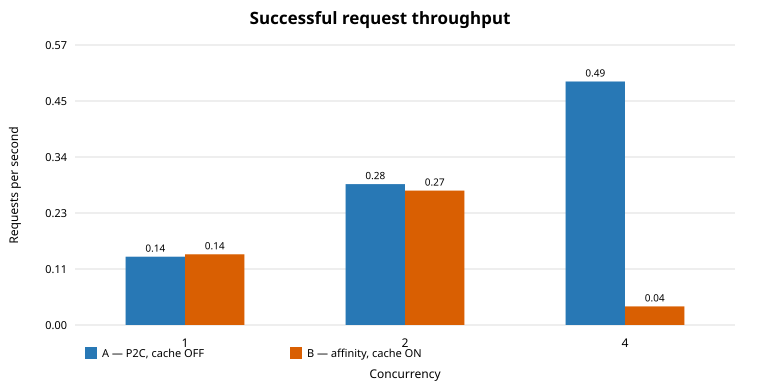

In [3]:
COLORS = {"A — P2C, cache OFF": "#2878B5", "B — affinity, cache ON": "#D95F02"}

def grouped_svg(metric, title, ylabel, width=760, height=390):
    concurrencies = [1, 2, 4]
    names = list(CONFIGS)
    vals = {(r["config"], r["concurrency"]): float(r[metric]) for r in rows}
    top = max(vals.values()) * 1.15 or 1
    left, right, upper, bottom = 75, 25, 45, 65
    plot_w, plot_h = width-left-right, height-upper-bottom
    p = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
         '<rect width="100%" height="100%" fill="white"/>',
         f'<text x="{width/2}" y="24" text-anchor="middle" font-family="sans-serif" font-size="17" font-weight="bold">{html.escape(title)}</text>']
    for i in range(6):
        v, y = top*i/5, upper+plot_h-plot_h*i/5
        p += [f'<line x1="{left}" x2="{left+plot_w}" y1="{y:.1f}" y2="{y:.1f}" stroke="#ddd"/>',
              f'<text x="{left-8}" y="{y+4:.1f}" text-anchor="end" font-family="sans-serif" font-size="11">{v:.2f}</text>']
    group_w, bar_w = plot_w/len(concurrencies), plot_w/len(concurrencies)*0.27
    for gi, c in enumerate(concurrencies):
        center = left+group_w*(gi+0.5)
        for ni, name in enumerate(names):
            value = vals[(name, c)]; bar_h = value/top*plot_h
            x = center+(ni-0.5)*bar_w-bar_w/2; y = upper+plot_h-bar_h
            p += [f'<rect x="{x:.1f}" y="{y:.1f}" width="{bar_w:.1f}" height="{bar_h:.1f}" fill="{COLORS[name]}"/>',
                  f'<text x="{x+bar_w/2:.1f}" y="{max(upper+10,y-5):.1f}" text-anchor="middle" font-family="sans-serif" font-size="10">{value:.2f}</text>']
        p.append(f'<text x="{center:.1f}" y="{upper+plot_h+22}" text-anchor="middle" font-family="sans-serif" font-size="12">{c}</text>')
    p += [f'<text x="{left+plot_w/2}" y="{height-12}" text-anchor="middle" font-family="sans-serif" font-size="12">Concurrency</text>',
          f'<text transform="translate(18 {upper+plot_h/2}) rotate(-90)" text-anchor="middle" font-family="sans-serif" font-size="12">{html.escape(ylabel)}</text>']
    for i, name in enumerate(names):
        p += [f'<rect x="{left+10+i*205}" y="{height-43}" width="12" height="12" fill="{COLORS[name]}"/>',
              f'<text x="{left+27+i*205}" y="{height-33}" font-family="sans-serif" font-size="11">{html.escape(name)}</text>']
    return ''.join(p+['</svg>'])

display(SVG(grouped_svg("request_throughput_per_s", "Successful request throughput", "Requests per second")))

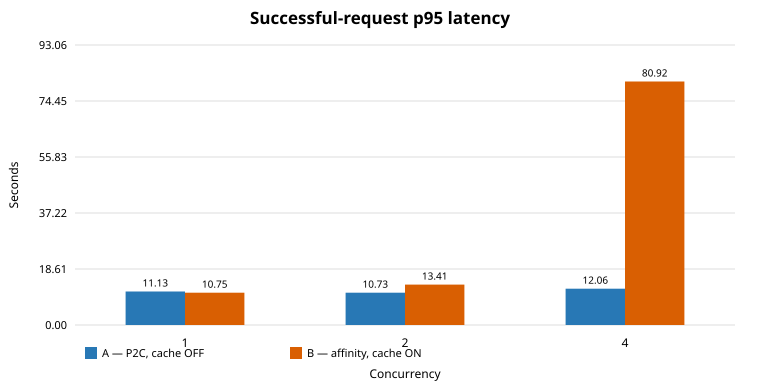

In [4]:
display(SVG(grouped_svg("latency_p95_s", "Successful-request p95 latency", "Seconds")))

## Cluster inference telemetry

Values below are sampled maxima across each saved range and its returned series, not phase averages. TTFT is the maximum observed aggregate p95 estimate, not per-request TTFT. TPOT is unavailable where the saved query contains no finite samples. Inter-token latency was not collected because the application requests are non-streaming. GPU and KV values describe the busiest observed sample, not summed cluster utilization. Saved ranges include short padding around phases and rate windows may overlap previous activity.

In [5]:
def metric_max(config_path, concurrency, key):
    payload = json.loads((config_path / f"metrics-c{concurrency}.json").read_text())
    values = []
    for series in payload.get(key, {}).get("result", []):
        for _, raw in series.get("values", []):
            try:
                value = float(raw)
            except (TypeError, ValueError):
                continue
            if math.isfinite(value):
                values.append(value)
    return max(values) if values else None

def fmt(value):
    return "Unavailable" if value is None else f"{value:.4g}"

cluster_runs = {**CONFIGS, "Current orchestration A (admission-limited)": ROOT / "benchmarks/config-a-orchestrated/run-1"}
metrics = [
    ("ttft_p95", "Aggregate TTFT p95 peak (s)"),
    ("tpot_p95", "Aggregate TPOT p95 peak (s)"),
    ("e2e_p95", "Engine E2E p95 peak (s)"),
    ("kv_cache", "KV usage peak (fraction)"),
    ("running", "Engine running requests peak"),
    ("waiting", "Engine waiting requests peak"),
    ("serve_queued", "Serve queue peak"),
    ("gpu_utilization", "GPU utilization peak (%)"),
    ("gpu_memory_mb", "GPU memory peak (MB)"),
]
for label, path in cluster_runs.items():
    display(Markdown(f"### {label}"))
    phases = json.loads((path / "summary.json").read_text())["phases"]
    concurrencies = [phase["concurrency"] for phase in phases]
    lines = ["| Metric | " + " | ".join(f"C={c}" for c in concurrencies) + " |",
             "|---|" + "---|" * len(concurrencies)]
    for key, title in metrics:
        lines.append("| " + title + " | " + " | ".join(fmt(metric_max(path, c, key)) for c in concurrencies) + " |")
    lines.append("| Per-request inter-token latency | " + " | ".join("Not collected" for _ in concurrencies) + " |")
    display(Markdown("\n".join(lines)))


### A — P2C, cache OFF

| Metric | C=1 | C=2 | C=4 |
|---|---|---|---|
| Aggregate TTFT p95 peak (s) | 0.9594 | 0.4875 | 0.4875 |
| Aggregate TPOT p95 peak (s) | Unavailable | Unavailable | Unavailable |
| Engine E2E p95 peak (s) | 8.75 | 8.75 | 8.75 |
| KV usage peak (fraction) | 0.01128 | 0.008928 | 0.01115 |
| Engine running requests peak | 1 | 1 | 1 |
| Engine waiting requests peak | 0 | 0 | 0 |
| Serve queue peak | 0 | 0 | 0 |
| GPU utilization peak (%) | 100 | 100 | 100 |
| GPU memory peak (MB) | 3.682e+04 | 3.682e+04 | 3.682e+04 |
| Per-request inter-token latency | Not collected | Not collected | Not collected |

### B — affinity, cache ON

| Metric | C=1 | C=2 | C=4 |
|---|---|---|---|
| Aggregate TTFT p95 peak (s) | 0.9479 | 0.485 | 0.4437 |
| Aggregate TPOT p95 peak (s) | Unavailable | Unavailable | Unavailable |
| Engine E2E p95 peak (s) | 9.493 | 8.75 | 8.75 |
| KV usage peak (fraction) | 0.01538 | 0.01538 | 0.01132 |
| Engine running requests peak | 1 | 1 | 1 |
| Engine waiting requests peak | 0 | 0 | 0 |
| Serve queue peak | 0 | 0 | 3 |
| GPU utilization peak (%) | 100 | 100 | 100 |
| GPU memory peak (MB) | 3.67e+04 | 3.67e+04 | 3.67e+04 |
| Per-request inter-token latency | Not collected | Not collected | Not collected |

### Current orchestration A (admission-limited)

| Metric | C=1 | C=2 | C=4 |
|---|---|---|---|
| Aggregate TTFT p95 peak (s) | 0.4875 | 0.4875 | 0.4875 |
| Aggregate TPOT p95 peak (s) | Unavailable | Unavailable | Unavailable |
| Engine E2E p95 peak (s) | 9.5 | 8.5 | 8.5 |
| KV usage peak (fraction) | 0.01132 | 0.01059 | 0.01059 |
| Engine running requests peak | 1 | 1 | 1 |
| Engine waiting requests peak | 0 | 0 | 0 |
| Serve queue peak | 0 | 0 | 0 |
| GPU utilization peak (%) | 100 | 100 | 100 |
| GPU memory peak (MB) | 3.682e+04 | 3.682e+04 | 3.682e+04 |
| Per-request inter-token latency | Not collected | Not collected | Not collected |

## Failure evidence

Failures remain in `requests.jsonl`; they are not included in successful-request latency percentiles.

In [6]:
failures = [(name, row) for name, records in requests.items() for row in records
            if row.get("phase") != "warmup" and not row.get("ok")]
print(f"Measured failures: {len(failures)}")
for name, row in failures:
    print(f"- {name}: seq={row['sequence']} phase={row['phase']} status={row['status_code']} "
          f"latency={row['latency_s']:.2f}s — {row['question']}")

Measured failures: 4
- B — affinity, cache ON: seq=26 phase=c4 status=502 latency=124.70s — Trace a text request from the gateway through routing, worker selection, and completion.
- B — affinity, cache ON: seq=28 phase=c4 status=502 latency=125.66s — Explain how prefill and decode KV transfer works with Mooncake.
- B — affinity, cache ON: seq=29 phase=c4 status=502 latency=124.65s — How does the planner decide whether to add prefill or decode replicas?
- B — affinity, cache ON: seq=30 phase=c4 status=502 latency=122.76s — Propose adding a circuit breaker to overflow calls. Name the files and tests to change.


## What the two-worker comparison shows

**Configuration A — Power of Two Choices routing with prefix caching disabled — handled increasing concurrency well in this run.**

- From C=1 to C=4, throughput rose from **0.138 to 0.492 successful requests/s**, approximately **3.6×**.
- Median latency stayed fairly stable: **6.38 → 6.62 seconds**.
- All **36 measured requests** across the three phases succeeded.

The application completed substantially more work concurrently with little increase in typical response time. At **0.492 requests/s**, the system averaged roughly one completion every **2.03 seconds**, while individual successful requests still took about **6.62 seconds** at the median because requests overlapped. This is an average completion rate, not evenly spaced completions.

**Configuration B — Ray prefix-affinity routing with vLLM prefix caching enabled — was comparable at low concurrency but degraded sharply at C=4.**

- At C=1, B was slightly faster than A. One short run does not establish an advantage.
- At C=2, B had a lower median (**5.78 vs 6.46 seconds**) but a higher p95 (**13.41 vs 10.73 seconds**): typical requests were faster, while the slower requests took longer.
- At C=4, only **8/12 requests succeeded**. Their median latency was **43.60 seconds**, p95 was **80.92 seconds**, and successful throughput fell to **0.038 requests/s**. The other four requests returned HTTP 502 in the saved records.

Failed requests are excluded from p50/p95, but the time spent waiting for them contributes to the phase duration used for throughput. B's C=4 latency therefore describes only eight successful requests; overall success was **66.7%**.

**Conclusion:** the P2C/cache-OFF configuration was more reliable and sustained better throughput at C=4 in this experiment. This does not prove prefix caching caused B's degradation: both caching and routing changed, only one run per configuration was collected, and each phase contained just 12 requests. A final controlled comparison should hold gateway routing constant and change only caching, with repeated runs.


## Reproducibility checks

In [7]:
assert [p["successful"] for p in summaries["A — P2C, cache OFF"]["phases"]] == [12, 12, 12]
assert [p["successful"] for p in summaries["B — affinity, cache ON"]["phases"]] == [12, 12, 8]
assert len(failures) == 4 and all(row["status_code"] == 502 for _, row in failures)
assert "enable_prefix_caching: false" in (CONFIGS["A — P2C, cache OFF"] / "rayservice.yaml").read_text()
assert "enable_prefix_caching: true" in (CONFIGS["B — affinity, cache ON"] / "rayservice.yaml").read_text()
print("Evidence assertions passed: summaries, failures, and serving manifests agree.")

Evidence assertions passed: summaries, failures, and serving manifests agree.


## Historical evidence limits

One run per profile; no isolated prefix workload; non-streaming requests; no semantic answer scoring. The following sections analyze newer orchestration evidence separately.

## Current live gateway smoke evidence

Collected independently from the application stress run. Short direct gateway calls demonstrate integration, not sustained capacity. Same-worker affinity is not proof of a cache hit; batch acceptance is not proof of priority ordering.

In [8]:
EVIDENCE = ROOT / "benchmarks/submission-evidence"
smoke = json.loads((EVIDENCE / "orchestration-smoke.json").read_text())
print("Collected:", smoke.get("started_at"))
lines = ["| Live check | Result |", "|---|---|"]
for check in smoke["checks"]:
    lines.append(f"| {check['name']} | {'PASS' if check['passed'] else 'FAIL'} |")
display(Markdown("\n".join(lines)))
print(json.dumps(smoke.get("affinity"), indent=2))


Collected: 2026-10-07T04:49:17.285364+00:00
{
  "first": {
    "x-graphserve-request-id": "211d4e96b6bc471cbcf427a94b9cc698",
    "x-graphserve-worker": "a",
    "x-graphserve-placement": "least_loaded",
    "x-graphserve-hop": "cold_start",
    "x-graphserve-queue-wait-ms": "0.17"
  },
  "second": {
    "x-graphserve-request-id": "59bc128234d1498e8f2eda0aa9e3a16c",
    "x-graphserve-worker": "a",
    "x-graphserve-placement": "prefix_affinity",
    "x-graphserve-hop": "same_worker",
    "x-graphserve-queue-wait-ms": "0.19"
  }
}


| Live check | Result |
|---|---|
| two healthy stable workers | PASS |
| invalid JSON | PASS |
| wrong model | PASS |
| streaming disabled | PASS |
| context budget | PASS |
| invalid priority | PASS |
| affinity requests succeed | PASS |
| first request is cold | PASS |
| repeat stays on worker | PASS |
| unique prefixes reach both workers | PASS |
| batch priority accepted | PASS |
| orchestration metrics exposed | PASS |

## Current orchestrated run: admission-limited traffic

This is a single baseline-labeled run, not a final A/B comparison. Adjacent phases share the repository tenant token window. Rejections therefore confound a concurrency/capacity comparison. The directory does not contain a contemporaneous deployment manifest or environment capture, so the runtime configuration is not independently verified.

In [9]:
current_path = ROOT / "benchmarks/config-a-orchestrated/run-1"
current = json.loads((current_path / "summary.json").read_text())
current_requests = [json.loads(line) for line in (current_path / "requests.jsonl").read_text().splitlines() if line.strip()]
measured = [r for r in current_requests if r.get("phase") != "warmup"]
from collections import Counter
print("UTC start:", current["started_at"], "Repository:", current["repository_id"], "Scope:", current["scope"])
lines = ["| C | Success / total | Statuses | Success/s | Success p95 seconds | Queue p95 ms | Workers |", "|---|---|---|---|---|---|---|"]
for p in current["phases"]:
    serving = p.get("serving", {})
    lines.append(f"| {p['concurrency']} | {p['successful']}/{p['requests']} | {p['status_counts']} | {p['request_throughput_per_s']:.3f} | {p['latency_p95_s']:.3f} | {serving.get('queue_wait_p95_ms')} | {serving.get('workers')} |")
display(Markdown("\n".join(lines)))
rejections = Counter(str(r.get("response", {}).get("detail")) for r in measured if not r.get("ok"))
print("Observed rejection reasons:", dict(rejections))
print("Retry-After values:", dict(Counter((r.get("response_headers") or {}).get("retry-after", "missing") for r in measured if not r.get("ok"))))
for p in current["phases"]:
    records = [r for r in measured if r["phase"] == f"c{p['concurrency']}"]
    assert len(records) == p["requests"]
    assert sum(bool(r.get("ok")) for r in records) == p["successful"]


UTC start: 2026-10-07T04:49:45.802988+00:00 Repository: 46104a869aaa639f02058087 Scope: class9
Observed rejection reasons: {'tenant_tokens': 23}
Retry-After values: {'5': 3, '3': 8, '1': 4, '7': 2, '2': 3, '4': 3}


| C | Success / total | Statuses | Success/s | Success p95 seconds | Queue p95 ms | Workers |
|---|---|---|---|---|---|---|
| 1 | 8/12 | {'200': 8, '429': 4} | 0.156 | 9.574 | 0.1765 | {'b': 8} |
| 2 | 3/12 | {'429': 9, '200': 3} | 0.204 | 4.525 | 0.223 | {'b': 3} |
| 4 | 2/12 | {'429': 10, '200': 2} | 0.127 | 11.527 | 0.169 | {'b': 2} |

The saved run has 13 successful and 23 rejected measured requests. All recorded rejection details are `tenant_tokens`. Successful final-response serving metadata reports worker b and same-worker affinity. Low queue wait in these successes does not demonstrate queue saturation or balanced use of both GPUs. A smaller p95 with fewer successes does not establish an improvement. Final-response metadata can also omit earlier attempts when an answer was retried.

## Interpretation and next measurements

- Historical A/B both used two GPU workers. Their caching and routing settings changed together, preventing attribution to caching alone.
- The newer run used the orchestrated cluster, but successful final-response records all identify worker b. It does not demonstrate balanced two-worker throughput. The separate live smoke test reached both workers.
- The newer run has 23 tenant-budget rejections out of 36 measured requests. Treat it as admission-policy evidence; do not rank GPU capacity from its successful-request latency alone.
- TPOT queries have no saved samples. Per-request TTFT and inter-token latency require additional measurement; do not substitute zeros or end-to-end latency.
- Repeat final A/B with identical gateway policy, isolated prefix workloads, controlled tenant budgets, runtime manifests and node placement captured for each run.

## Reproduce this report

Execute all cells from the repository root using Python and IPython. All cells read saved cluster evidence; no active VM is needed. Required inputs are the two historical multinode benchmark directories, `benchmarks/config-a-orchestrated/run-1`, and `benchmarks/submission-evidence/orchestration-smoke.json`. Existing raw evidence and local policy tests remain in the repository but are not presented as cluster performance results. Export and review the final PDF after completing the missing measurements.
